In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Pfad zum Bild, das vorbereitet werden soll.
IMAGE_PATH = "bilder/nrw/2.jpg"

# Zwischenstand fuer das zweite Notebook.
PREPROCESSING_OUTPUT_PATH = "imbussschluessel_vorverarbeitung.npz"


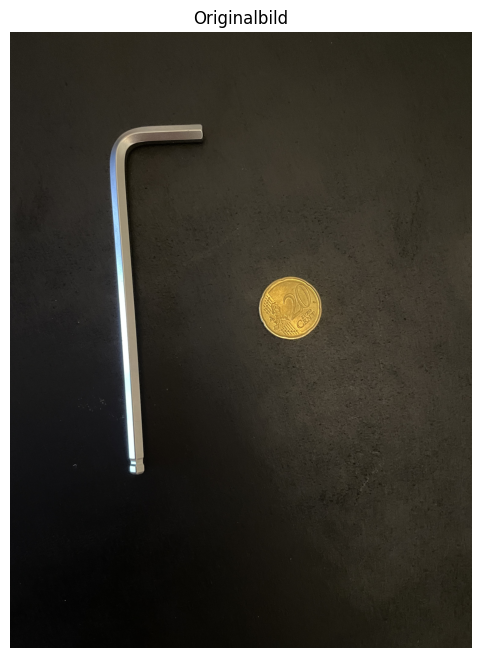

In [10]:
# ============================================================
# 1. Bild laden
# ============================================================
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Bild nicht gefunden: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title("Originalbild")
plt.axis("off")
plt.show()


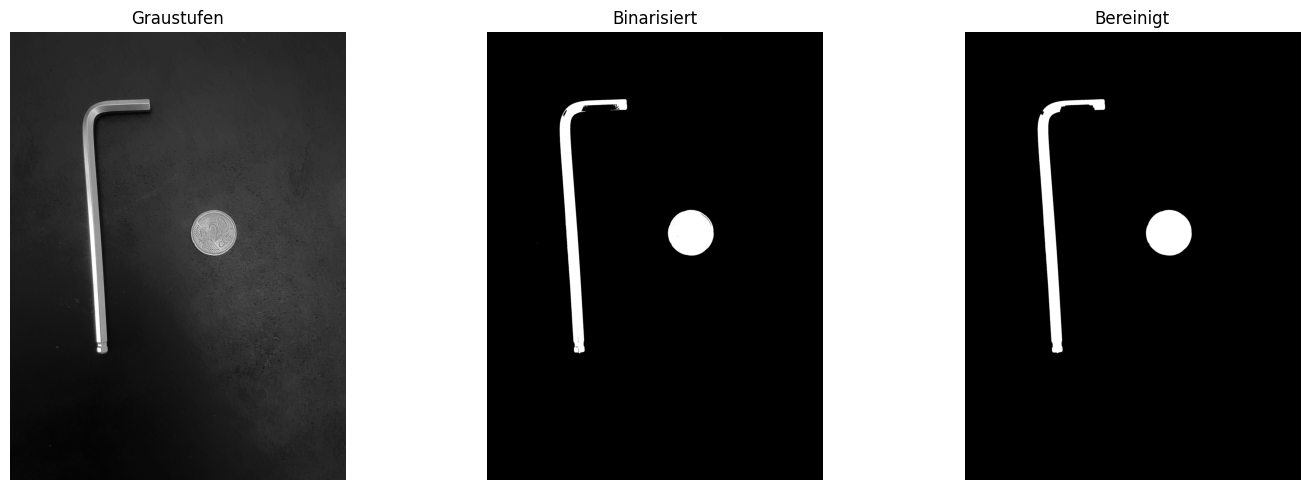

In [11]:
# ============================================================
# 2. Vorverarbeitung
# Ziel: Bild fuer die Hough-Transformation vorbereiten
# ============================================================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 0)

_, binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((5, 5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, image, title in zip(
    axes,
    [gray, binary, clean],
    ["Graustufen", "Binarisiert", "Bereinigt"]
):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


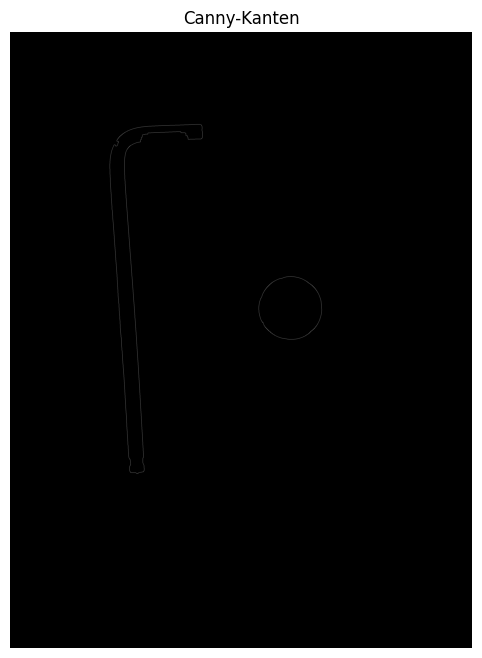

Vorverarbeitung gespeichert: /Users/koch/Library/CloudStorage/Nextcloud-york@cloud․gfwm․eu/Studium/Master/Computer Vision/cv_praktikum_1/imbussschluessel_vorverarbeitung.npz


In [12]:
# ============================================================
# 3. Kantenbild fuer Hough erzeugen und speichern
# ============================================================

edges = cv2.Canny(clean, 50, 150, apertureSize=3)

plt.figure(figsize=(8, 8))
plt.imshow(edges, cmap="gray")
plt.title("Canny-Kanten")
plt.axis("off")
plt.show()

np.savez_compressed(
    PREPROCESSING_OUTPUT_PATH,
    img=img,
    img_rgb=img_rgb,
    gray=gray,
    binary=binary,
    clean=clean,
    edges=edges,
    image_path=np.array(IMAGE_PATH),
)

print(f"Vorverarbeitung gespeichert: {Path(PREPROCESSING_OUTPUT_PATH).resolve()}")
